In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

In [2]:
df_train_clean = pd.read_csv("../../data/processed/01.3/accidents_advance_clean.csv")

df_train_clean.head(10)

,Severity,Start_Time,Start_Lat,Start_Lng,Distance(mi),Description,Street,City,County,State,...,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Duration(min),Start_Date,Hour,Month,Weather_Group
0,3,2016-11-08 08:50:37,29.718655,-95.321053,0.009950,Accident on I-45 Northbound at I-45 Exits 43A ...,I-45 N,Houston,Harris,TX,...,False,Day,Day,Day,Day,3.405079,2016-11-08,8,11,Cloudy
1,2,2021-07-26 07:04:56,38.927551,-121.080093,0.000000,Right hand shoulder blocked due to accident on...,Taylor Ln,Auburn,Placer,CA,...,False,Day,Day,Day,Day,3.862833,2021-07-26,7,7,Clear
2,2,2018-10-24 08:23:38,34.776241,-86.672829,0.000000,Lane blocked due to accident on AL-255 Researc...,Highway 255,Huntsville,Madison,AL,...,False,Day,Day,Day,Day,3.422633,2018-10-24,8,10,Clear
3,3,2019-07-11 10:42:48,42.384880,-83.149467,0.470004,Entry ramp to I-96 Westbound from Davison West...,Edward J Jeffries Fwy,Detroit,Wayne,MI,...,False,Day,Day,Day,Day,4.784571,2019-07-11,10,7,Clear
4,2,2020-11-06 01:29:00,33.776575,-117.837134,0.387980,1023: NB 55 JNO 22. SV REAR ENDED VV AND WAS L...,Garden Grove Fwy,Orange,Orange,CA,...,False,Night,Night,Night,Night,4.952535,2020-11-06,1,11,Clear
5,2,2021-07-02 15:22:00,36.989497,-121.935657,0.033435,Incident on PARK AVE WB near SOQUEL DR Expect ...,Park Ave N,Soquel,Santa Cruz,CA,...,False,Day,Day,Day,Day,5.758376,2021-07-02,15,7,Cloudy
6,2,2019-08-09 08:44:18,30.419380,-91.096611,0.000000,Accident on LA-73 Jefferson Hwy at LA-3064 Ess...,Essen Ln,Baton Rouge,East Baton Rouge,LA,...,False,Day,Day,Day,Day,4.665638,2019-08-09,8,8,Cloudy
7,2,2021-12-10 07:02:30,33.194519,-111.901301,1.015955,Stationary traffic on I-10 E - Pearl Harbor Me...,I-10 E,Maricopa,Pinal,AZ,...,False,Night,Day,Day,Day,4.248495,2021-12-10,7,12,Clear
8,3,2021-04-26 19:57:38,29.384928,-98.512321,0.000000,Three lanes blocked due to accident on I-35 So...,I-35 N,San Antonio,Bexar,TX,...,False,Day,Day,Day,Day,5.332880,2021-04-26,19,4,Clear
9,2,2017-04-18 19:05:08,26.589575,-81.703766,0.000000,Accident on 25th St at Curtis Ave.,25th St SW,Lehigh Acres,Lee,FL,...,False,Day,Day,Day,Day,3.751463,2017-04-18,19,4,Cloudy


# Feature Engineering

จาก EDA พบ 4 กลุ่ม patterns ที่น่าสร้างเป็น features:

| กลุ่ม | Features | Insight จาก EDA |
|-------|----------|----------------|
| **1. Time** | Rush hour, Weekend, Season, Night, Time period | Accident พุ่งช่วง 7–9 และ 16–18 น. ชัดเจน |
| **2. Weather Risk** | Bad weather flag, Visibility, Temp, Wind, Precip, Risk score | Fog/Severe มี avg severity สูงกว่า Overall mean |
| **3. Infrastructure** | Count, Intersection, Traffic control, Complex road | Traffic_Signal, Junction สัมพันธ์กับ severity ใน heatmap |
| **4. Interaction** | Rush×Night, BadWeather×Night, Intersection×Weather, Freezing×Precip | combinations amplify risk |
| **5. Encoding** | Weather ordinal, Wind sin/cos, State frequency | แปลง categorical → numeric อย่างถูกต้อง |

> **Note:** ค่า numeric ถูก transform ใน 01.3 แล้ว (`Temperature²`, `Visibility²`, `Wind√`, `log1p(Precip/Duration/Distance)`)  
> threshold ใน Group 2 คำนวณใน transformed space

In [3]:
df = df_train_clean.copy()

# Parse datetime to extract Day_of_Week
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['Day_of_Week'] = df['Start_Time'].dt.dayofweek  # 0=Monday, 6=Sunday

# Rush hour: morning 7–9, evening 16–18
df['Is_Rush_Hour'] = df['Hour'].apply(
    lambda h: 1 if (7 <= h <= 9) or (16 <= h <= 18) else 0
)

# Weekend flag
df['Is_Weekend'] = (df['Day_of_Week'] >= 5).astype(int)

# Season from month
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
               3: 'Spring', 4: 'Spring', 5: 'Spring',
               6: 'Summer', 7: 'Summer', 8: 'Summer',
               9: 'Fall',   10: 'Fall',  11: 'Fall'}
df['Season'] = df['Month'].map(season_map)

# Night flag from Sunrise_Sunset
df['Is_Night'] = (df['Sunrise_Sunset'].astype(str) == 'Night').astype(int)

# Time period of day
def time_period(h):
    if   5 <= h < 12:  return 'Morning'
    elif 12 <= h < 17: return 'Afternoon'
    elif 17 <= h < 21: return 'Evening'
    else:              return 'Night'

df['Time_Period'] = df['Hour'].apply(time_period)

print("=== Group 1: Time Features ===")
print(f"Is_Rush_Hour : {df['Is_Rush_Hour'].mean()*100:.1f}%  |  avg Severity: {df.groupby('Is_Rush_Hour')['Severity'].mean().to_dict()}")
print(f"Is_Weekend   : {df['Is_Weekend'].mean()*100:.1f}%  |  avg Severity: {df.groupby('Is_Weekend')['Severity'].mean().to_dict()}")
print(f"Is_Night     : {df['Is_Night'].mean()*100:.1f}%  |  avg Severity: {df.groupby('Is_Night')['Severity'].mean().to_dict()}")
print(f"\nSeason distribution:\n{df['Season'].value_counts().to_string()}")
print(f"\nTime_Period distribution:\n{df['Time_Period'].value_counts().to_string()}")

=== Group 1: Time Features ===
Is_Rush_Hour : 40.9%  |  avg Severity: {0: 2.2346274783688838, 1: 2.221016109888203}
Is_Weekend   : 15.2%  |  avg Severity: {0: 2.2201728766277764, 1: 2.278818363851294}
Is_Night     : 30.5%  |  avg Severity: {0: 2.2258387221577407, 1: 2.2363991274358184}

Season distribution:
Season
Winter    1561330
Fall      1502290
Spring    1204483
Summer    1200989

Time_Period distribution:
Time_Period
Morning      2072317
Afternoon    1604965
Evening      1077596
Night         714214


## Group 2: Weather Risk Features

สร้าง binary flags จากข้อมูลอากาศ โดยคำนวณ threshold ใน **transformed space** (ค่าถูก transform ใน 01.3 แล้ว):

| Feature | Threshold (transformed) | ≈ Original |
|---------|------------------------|-----------|
| `Low_Visibility` | `Visibility² < 4` | < 2 miles |
| `Is_Freezing_Temp` | `Temperature² < 1024` | < 32°F |
| `High_Wind` | `Wind_Speed√ > 4.47` | > 20 mph |
| `Has_Precipitation` | `log1p(Precip) > 0` | any rain/snow |
| `Is_Bad_Weather` | Weather_Group ∈ {Rain, Fog, Snow_Ice, Severe} | — |

`Weather_Risk_Score` = ผลรวม binary flags ทั้ง 5 ตัว (0–5) — ใช้เป็น composite feature

In [4]:
bad_weather = {'Rain', 'Fog', 'Snow_Ice', 'Severe'}
df['Is_Bad_Weather'] = df['Weather_Group'].isin(bad_weather).astype(int)

# Thresholds computed in transformed space (see 01.3 transforms):
# Visibility²  < 4    ≈ original Visibility < 2 mi
# Temperature² < 1024 ≈ original Temperature < 32°F
# Wind√        > 4.47 ≈ original Wind_Speed > 20 mph
# log1p(Precip) > 0   = any precipitation

df['Low_Visibility']   = (df['Visibility(mi)']    <  4.0 ).astype(int)
df['Is_Freezing_Temp'] = (df['Temperature(F)']    < 1024.0).astype(int)
df['High_Wind']        = (df['Wind_Speed(mph)']   >  4.47).astype(int)
df['Has_Precipitation']= (df['Precipitation(in)'] >  0.0 ).astype(int)

# Composite risk score 0–5
df['Weather_Risk_Score'] = (
    df['Is_Bad_Weather'] + df['Low_Visibility'] +
    df['Is_Freezing_Temp'] + df['High_Wind'] + df['Has_Precipitation']
)

print("=== Group 2: Weather Risk Features ===")
risk_cols = ['Is_Bad_Weather', 'Low_Visibility', 'Is_Freezing_Temp', 'High_Wind', 'Has_Precipitation']
for c in risk_cols:
    pct = df[c].mean() * 100
    avg = df[df[c] == 1]['Severity'].mean()
    print(f"  {c:<25}: {pct:5.1f}% True  |  avg Severity when True: {avg:.3f}")

print(f"\nWeather_Risk_Score distribution:")
print(df['Weather_Risk_Score'].value_counts().sort_index().rename('count').to_string())
print(f"\nAvg Severity by Weather_Risk_Score:")
print(df.groupby('Weather_Risk_Score')['Severity'].mean().rename('avg_severity').to_string())

=== Group 2: Weather Risk Features ===
  Is_Bad_Weather           :  12.8% True  |  avg Severity when True: 2.252
  Low_Visibility           :   3.2% True  |  avg Severity when True: 2.241
  Is_Freezing_Temp         :   7.0% True  |  avg Severity when True: 2.262
  High_Wind                :   2.5% True  |  avg Severity when True: 2.234
  Has_Precipitation        :  31.3% True  |  avg Severity when True: 2.343

Weather_Risk_Score distribution:
Weather_Risk_Score
0    3145605
1    1702655
2     487814
3     101852
4      29439
5       1727

Avg Severity by Weather_Risk_Score:
Weather_Risk_Score
0    2.171113
1    2.314495
2    2.290912
3    2.279582
4    2.274670
5    2.324841


## Group 3: Road Infrastructure Features

จาก EDA heatmap พบว่า `Traffic_Signal`, `Junction`, `Crossing` มีความสัมพันธ์กับ Severity  
สร้าง composite features จาก 13 bool columns:

| Feature | นิยาม |
|---------|-------|
| `Infrastructure_Count` | ผลรวมของ bool columns ทั้ง 13 ตัว (0–13) |
| `Is_Intersection` | `Crossing` OR `Junction` |
| `Has_Traffic_Control` | `Traffic_Signal` OR `Stop` |
| `Is_Complex_Road` | `Is_Intersection` AND `Has_Traffic_Control` |

> bool columns ที่อ่านกลับจาก CSV อาจเป็น string — แปลงให้ถูก dtype ก่อนใช้งาน

In [5]:
bool_cols = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
             'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
             'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop']

# Ensure bool dtype (CSV may read back as string 'True'/'False')
for c in bool_cols:
    df[c] = df[c].astype(str).str.lower().map({'true': True, 'false': False}).fillna(False)

# Count of infrastructure features near accident site
df['Infrastructure_Count'] = df[bool_cols].sum(axis=1)

# Composite binary flags
df['Is_Intersection']     = (df['Crossing'] | df['Junction']).astype(int)
df['Has_Traffic_Control'] = (df['Traffic_Signal'] | df['Stop']).astype(int)
# Intersection + control device = "complex road"
df['Is_Complex_Road']     = ((df['Is_Intersection'] == 1) & (df['Has_Traffic_Control'] == 1)).astype(int)

print("=== Group 3: Infrastructure Features ===")
print(f"Infrastructure_Count  mean : {df['Infrastructure_Count'].mean():.3f}")
for c in ['Is_Intersection', 'Has_Traffic_Control', 'Is_Complex_Road']:
    pct = df[c].mean() * 100
    avg = df[df[c] == 1]['Severity'].mean()
    print(f"  {c:<25}: {pct:5.1f}% True  |  avg Severity when True: {avg:.3f}")

print(f"\nAvg Severity by Infrastructure_Count:")
print(df.groupby('Infrastructure_Count')['Severity'].mean().rename('avg_severity').to_string())

=== Group 3: Infrastructure Features ===
Infrastructure_Count  mean : 0.432
  Is_Intersection          :  19.0% True  |  avg Severity when True: 2.165
  Has_Traffic_Control      :  18.3% True  |  avg Severity when True: 2.088
  Is_Complex_Road          :   8.4% True  |  avg Severity when True: 2.066

Avg Severity by Infrastructure_Count:
Infrastructure_Count
0    2.266111
1    2.181222
2    2.071775
3    2.078071
4    2.085574
5    2.083333
6    2.032680
7    2.000000


## Group 4: Interaction Features

ความเสี่ยงของอุบัติเหตุไม่ได้มาจาก factor เดียว — combinations บางอย่างทำให้ severity สูงกว่าผลรวมของแต่ละปัจจัย:

| Feature | ความหมาย |
|---------|----------|
| `Rush_x_Night` | Rush hour ตอนมืด (เช่น เวร 4 โมงเย็นช่วงหน้าหนาว) |
| `BadWeather_x_Night` | อากาศแย่ + มืด |
| `Intersection_x_BadWeather` | ทางแยก + อากาศแย่ = ทัศนวิสัยกว้างน้อย |
| `Rush_x_BadWeather` | ชั่วโมงเร่งด่วน + ฝนตก/หมอก |
| `Freezing_x_Precip` | อุณหภูมิต่ำกว่าจุดเยือกแข็ง + มีน้ำฝน → ถนนเป็นน้ำแข็ง |

In [6]:
# Interaction: Rush hour × Night  (rush แต่มืด = ผิดปกติ)
df['Rush_x_Night']              = df['Is_Rush_Hour']    * df['Is_Night']
# Interaction: Bad weather × Night
df['BadWeather_x_Night']        = df['Is_Bad_Weather']  * df['Is_Night']
# Interaction: Intersection × Bad weather
df['Intersection_x_BadWeather'] = df['Is_Intersection'] * df['Is_Bad_Weather']
# Interaction: Rush hour × Bad weather
df['Rush_x_BadWeather']         = df['Is_Rush_Hour']    * df['Is_Bad_Weather']
# Interaction: Freezing + Precipitation → ถนนอาจเป็นน้ำแข็ง
df['Freezing_x_Precip']         = df['Is_Freezing_Temp'] * df['Has_Precipitation']

interact_cols = [
    'Rush_x_Night', 'BadWeather_x_Night',
    'Intersection_x_BadWeather', 'Rush_x_BadWeather', 'Freezing_x_Precip'
]

print("=== Group 4: Interaction Features ===")
for col in interact_cols:
    pct      = df[col].mean() * 100
    sev_true = df[df[col] == 1]['Severity'].mean()
    sev_base = df['Severity'].mean()
    print(f"  {col:<35}: {pct:5.1f}% True  |  ΔSeverity vs baseline = {sev_true - sev_base:+.3f}")

=== Group 4: Interaction Features ===
  Rush_x_Night                       :   5.8% True  |  ΔSeverity vs baseline = -0.007
  BadWeather_x_Night                 :   4.3% True  |  ΔSeverity vs baseline = +0.019
  Intersection_x_BadWeather          :   2.2% True  |  ΔSeverity vs baseline = -0.035
  Rush_x_BadWeather                  :   5.2% True  |  ΔSeverity vs baseline = +0.009
  Freezing_x_Precip                  :   2.2% True  |  ΔSeverity vs baseline = +0.142


## Group 5: Encoding & Cleanup

| Column | วิธี | เหตุผล |
|--------|------|--------|
| `Weather_Group` | Ordinal (เรียงตาม mean severity) | รักษา severity order ไว้ |
| `Wind_Direction` | Sin/Cos cyclical | ทิศทางเป็น circular — N กับ NNW ใกล้กัน ห้ามใช้ ordinal |
| `Season` | Ordinal Spring=0 → Winter=3 | มี natural order |
| `Time_Period` | Ordinal Morning=0 → Night=3 | มี natural order |
| `State` | Frequency encoding | หลีกเลี่ยง one-hot 50 columns |

**Drop:** text cardinality สูง (City, Street, Description), duplicate datetime, raw categorical ที่ encode แล้ว, twilight columns (redundant กับ Sunrise_Sunset)

In [7]:
# --- 1. Weather_Group → ordinal by mean severity ---
weather_sev_mean = df.groupby('Weather_Group')['Severity'].mean().sort_values()
weather_ordinal  = {g: i for i, g in enumerate(weather_sev_mean.index)}
df['Weather_Group_Enc'] = df['Weather_Group'].map(weather_ordinal)

print("Weather_Group ordinal encoding (0=lowest → highest avg severity):")
print(weather_sev_mean.rename('avg_severity').reset_index()
      .assign(ordinal=range(len(weather_sev_mean))).to_string(index=False))

# --- 2. Wind_Direction → sin/cos (cyclical encoding) ---
compass_deg = {
    'N': 0,   'NNE': 22.5,  'NE': 45,   'ENE': 67.5,
    'E': 90,  'ESE': 112.5, 'SE': 135,  'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225,  'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315,  'NNW': 337.5,
    'CALM': 0, 'VAR': 0
}
_deg = df['Wind_Direction'].map(compass_deg).fillna(0)
df['Wind_Dir_Sin'] = np.sin(np.radians(_deg))
df['Wind_Dir_Cos'] = np.cos(np.radians(_deg))

# --- 3. Season → ordinal ---
df['Season_Enc'] = df['Season'].map({'Spring': 0, 'Summer': 1, 'Fall': 2, 'Winter': 3})

# --- 4. Time_Period → ordinal ---
df['Time_Period_Enc'] = df['Time_Period'].map(
    {'Morning': 0, 'Afternoon': 1, 'Evening': 2, 'Night': 3}
)

# --- 5. State → frequency encoding ---
state_freq = df['State'].value_counts(normalize=True)
df['State_Freq_Enc'] = df['State'].map(state_freq)

# --- Drop high-cardinality & redundant columns ---
drop_cols = [
    'Start_Time', 'Start_Date', 'Description', 'Street',
    'City', 'County', 'Zipcode', 'Country', 'State',
    'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight',
    'Weather_Group', 'Wind_Direction', 'Season', 'Time_Period',
]
df_features = df.drop(columns=drop_cols, errors='ignore')

print(f"\nFinal shape: {df_features.shape[0]:,} rows × {df_features.shape[1]} features")
print("\nAll features (col: dtype):")
for col in df_features.columns:
    print(f"  {col:<35}: {str(df_features[col].dtype)}")

Weather_Group ordinal encoding (0=lowest → highest avg severity):
Weather_Group  avg_severity  ordinal
        Windy      2.177770        0
          Fog      2.192378        1
        Clear      2.201602        2
        Other      2.235543        3
       Severe      2.248400        4
       Cloudy      2.252155        5
         Rain      2.270407        6
     Snow_Ice      2.270420        7

Final shape: 5,469,092 rows × 52 features

All features (col: dtype):
  Severity                           : int64
  Start_Lat                          : float64
  Start_Lng                          : float64
  Distance(mi)                       : float64
  Temperature(F)                     : float64
  Wind_Chill(F)                      : float64
  Humidity(%)                        : float64
  Pressure(in)                       : float64
  Visibility(mi)                     : float64
  Wind_Speed(mph)                    : float64
  Precipitation(in)                  : float64
  Amenity      

Saved → ../../data/processed/03/accidents_features.csv
Shape: 5,469,092 rows × 52 cols

=== Feature Correlation with Severity (absolute) ===
Has_Precipitation       0.154952
Has_Traffic_Control     0.134308
Infrastructure_Count    0.122015
Weather_Risk_Score      0.107217
Is_Complex_Road         0.099237
Duration(min)           0.082231
State_Freq_Enc          0.076457
Start_Lat               0.069635
Is_Intersection         0.062126
Weather_Group_Enc       0.055652
Wind_Speed(mph)         0.054389
Start_Lng               0.053749
Pressure(in)            0.047808
Precipitation(in)       0.043936
Freezing_x_Precip       0.042850
Is_Weekend              0.042221
Season_Enc              0.031677
Day_of_Week             0.029470
Wind_Chill(F)           0.029408
Wind_Dir_Cos            0.024783


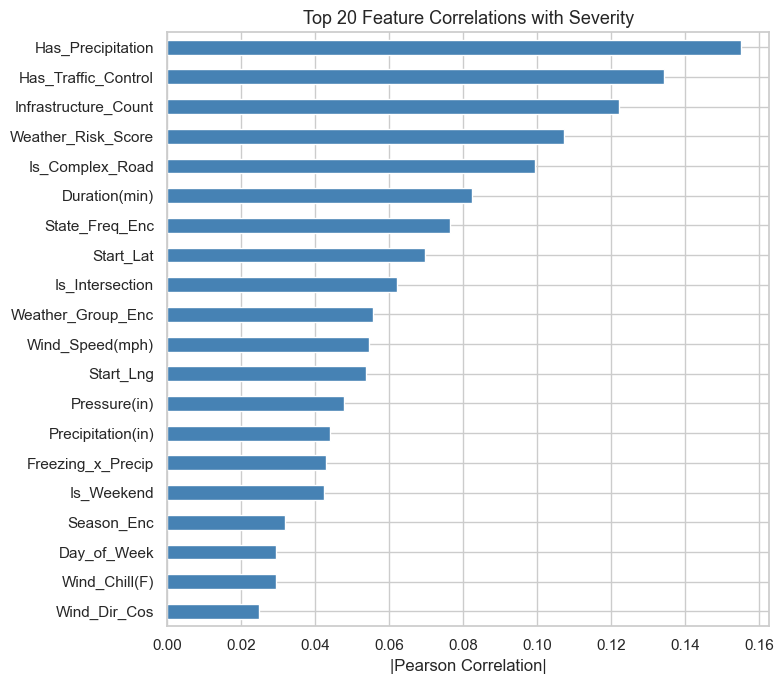

In [8]:
import os

save_dir = "../../data/processed/03"
os.makedirs(save_dir, exist_ok=True)

df_features.to_csv(f"{save_dir}/accidents_features.csv", index=False)
print(f"Saved → {save_dir}/accidents_features.csv")
print(f"Shape: {df_features.shape[0]:,} rows × {df_features.shape[1]} cols")

# Top correlated features with Severity
print("\n=== Feature Correlation with Severity (absolute) ===")
corr = df_features.select_dtypes(include='number').corr()['Severity'].abs()
corr = corr.drop('Severity').sort_values(ascending=False)
print(corr.head(20).to_string())

# Visualize
fig, ax = plt.subplots(figsize=(8, 7))
corr.head(20).sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Feature Correlations with Severity', fontsize=13)
ax.set_xlabel('|Pearson Correlation|')
plt.tight_layout()
plt.show()